In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Import our custom modules
from utils.data_loader import get_dataloaders, load_adjacency_matrix
from models.STGCN import STGCN_Model

# Set up hardware acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cuda


In [2]:
# Network Dimensions (Keep these as they are defined by your data)
NUM_NODES = 150 
IN_FEATURES = 1 
HISTORICAL_STEPS = 12 
PRED_STEPS = 12

# Updated Training Parameters from Grid Search
BATCH_SIZE = 32 
LEARNING_RATE = 0.005
WEIGHT_DECAY = 1e-4
EPOCHS = 50

In [3]:
# 1. Load the Adjacency Matrix and push to GPU
adj_matrix = load_adjacency_matrix('data/adj_mat_volume.pkl').to(device)
print(f"Adjacency Matrix Shape: {adj_matrix.shape}")

# 2. Load the DataLoaders
# We capture mean and std so we can un-normalize the predictions later
train_loader, val_loader, test_loader, data_mean, data_std = get_dataloaders(
    csv_path='data/sensor_volume_150.csv', 
    seq_len=HISTORICAL_STEPS, 
    pre_len=PRED_STEPS, 
    batch_size=BATCH_SIZE
)
print("DataLoaders ready.")

Adjacency Matrix Shape: torch.Size([150, 150])


c:\Users\hataj\Documents\UCLA Assignments\Winter 26\C147A\CS147A\utils\data_loader.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  pickle_data = pickle.load(f)


DataLoaders ready.


In [4]:
# Initialize Model
model = STGCN_Model(
    num_nodes=NUM_NODES, 
    in_features=IN_FEATURES, 
    historical_steps=HISTORICAL_STEPS, 
    pred_steps=PRED_STEPS
).to(device)

# Define Loss
criterion = nn.MSELoss()

# Updated Optimizer with Weight Decay
optimizer = optim.Adam(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

# Add a Learning Rate Scheduler
# This will cut the LR by half if the validation loss doesn't improve for 5 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5, 
    verbose=True
)

print(f"Model loaded with LR: {LEARNING_RATE} and WD: {WEIGHT_DECAY}")

Model loaded with LR: 0.005 and WD: 0.0001


c:\Users\hataj\anaconda3\envs\ECEC147A\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [5]:
train_losses = []
val_losses = []
best_val_loss = float('inf')

print(f"Starting Training on {device}...")

for epoch in range(EPOCHS):
    # ============================
    #       TRAINING PHASE
    # ============================
    model.train() 
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_X, adj_matrix)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ============================
    #      VALIDATION PHASE
    # ============================
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad(): # No gradients needed, saves memory
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            preds = model(batch_X, adj_matrix)
            v_loss = criterion(preds, batch_y)
            running_val_loss += v_loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # ============================
    #       SCHEDULER STEP
    # ============================
    # If val_loss plateaus, this will eventually drop the LR
    scheduler.step(avg_val_loss)
    
    # Track the best weights (Checkpointing)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_stgcn.pt')

    # Print status every 5 epochs
    if (epoch + 1) % 5 == 0:
        # Get current LR from optimizer to see if scheduler worked
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:2d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

print("\nTraining Complete!")

Starting Training on cuda...
Epoch [ 5/50] | Train Loss: 0.6360 | Val Loss: 0.7045 | LR: 0.005000
Epoch [10/50] | Train Loss: 0.6313 | Val Loss: 0.6805 | LR: 0.005000
Epoch [15/50] | Train Loss: 0.6289 | Val Loss: 0.6730 | LR: 0.005000
Epoch [20/50] | Train Loss: 0.6285 | Val Loss: 0.6792 | LR: 0.005000
Epoch [25/50] | Train Loss: 0.6287 | Val Loss: 0.6718 | LR: 0.002500
Epoch [30/50] | Train Loss: 0.6257 | Val Loss: 0.6693 | LR: 0.002500
Epoch [35/50] | Train Loss: 0.6255 | Val Loss: 0.6721 | LR: 0.002500
Epoch [40/50] | Train Loss: 0.6241 | Val Loss: 0.6655 | LR: 0.001250
Epoch [45/50] | Train Loss: 0.6242 | Val Loss: 0.6663 | LR: 0.001250
Epoch [50/50] | Train Loss: 0.6234 | Val Loss: 0.6686 | LR: 0.000625

Training Complete!


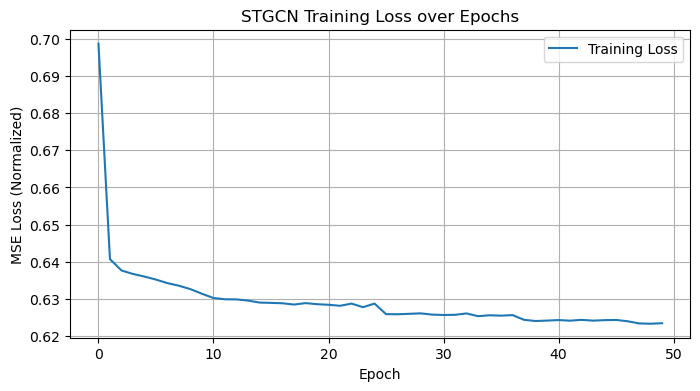

Final Training MSE Loss: 0.6234


In [6]:
# Plot the training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.title('STGCN Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (Normalized)')
plt.legend()
plt.grid(True)
plt.show()

# Final MSE:
print(f"Final Training MSE Loss: {train_losses[-1]:.4f}")

In [7]:
import numpy as np

# 1. Set model to evaluation mode (turns off dropout and batch norm tracking)
model.eval()

all_predictions = []
all_targets = []

print("Running testing phase...")
# 2. Turn off gradient calculation to save memory and speed up inference
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Get predictions
        preds = model(batch_X, adj_matrix)
        
        # Move back to CPU and convert to NumPy arrays for easier math
        all_predictions.append(preds.cpu().numpy())
        all_targets.append(batch_y.cpu().numpy())

# 3. Concatenate all batches into large arrays
# Shape will be: (Total_Test_Windows, 150_Nodes, 3_Steps)
all_predictions = np.concatenate(all_predictions, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# 4. Un-normalize the data (Inverse Z-Score: x = z * std + mean)
preds_unnorm = (all_predictions * data_std) + data_mean
targets_unnorm = (all_targets * data_std) + data_mean

# 5. Calculate Metrics
# MAE: On average, how many cars are we off by?
mae = np.mean(np.abs(preds_unnorm - targets_unnorm))

# RMSE: Penalizes larger errors more heavily
rmse = np.sqrt(np.mean(np.square(preds_unnorm - targets_unnorm)))

print("Testing Phase Complete!")
print(f"Overall Mean Absolute Error (MAE): {mae:.2f} volume units")
print(f"Overall Root Mean Squared Error (RMSE): {rmse:.2f} volume units")

Running testing phase...
Testing Phase Complete!
Overall Mean Absolute Error (MAE): 1431.43 volume units
Overall Root Mean Squared Error (RMSE): 1783.03 volume units


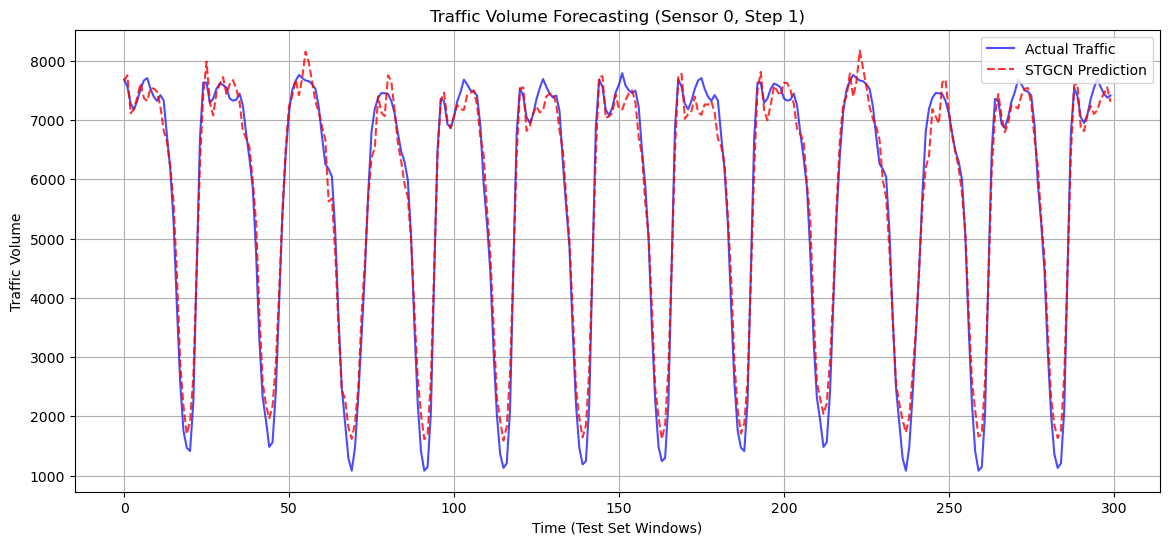

In [8]:
import matplotlib.pyplot as plt

# Let's inspect the first sensor (Node 0)
# And let's look at the prediction for the 1st time step (t+1, or 30 seconds out)
SENSOR_IDX = 0
TIME_STEP_IDX = 0 

# Extract just that slice of data
actual_traffic = targets_unnorm[:, SENSOR_IDX, TIME_STEP_IDX]
predicted_traffic = preds_unnorm[:, SENSOR_IDX, TIME_STEP_IDX]

# Plotting
plt.figure(figsize=(14, 6))

# We'll plot just a slice (e.g., the first 300 test windows) so the graph isn't too cluttered
PLOT_LENGTH = 300

plt.plot(actual_traffic[:PLOT_LENGTH], label='Actual Traffic', color='blue', alpha=0.7)
plt.plot(predicted_traffic[:PLOT_LENGTH], label='STGCN Prediction', color='red', alpha=0.8, linestyle='--')

plt.title(f'Traffic Volume Forecasting (Sensor {SENSOR_IDX}, Step {TIME_STEP_IDX+1})')
plt.xlabel('Time (Test Set Windows)')
plt.ylabel('Traffic Volume')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from models.baseline import NaiveBaseline

# 1. Initialize the baseline (no optimizer or loss function needed!)
baseline_model = NaiveBaseline(pred_steps=PRED_STEPS).to(device)

print("Running testing phase for Naive Baseline...")

# 2. Run the exact same evaluation logic
baseline_predictions = []
baseline_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Forward pass (adj_matrix is passed but ignored by the baseline)
        preds = baseline_model(batch_X, adj_matrix)
        
        baseline_predictions.append(preds.cpu().numpy())
        baseline_targets.append(batch_y.cpu().numpy())

# 3. Concatenate and Un-normalize
baseline_predictions = np.concatenate(baseline_predictions, axis=0)
baseline_targets = np.concatenate(baseline_targets, axis=0)

base_preds_unnorm = (baseline_predictions * data_std) + data_mean
base_targets_unnorm = (baseline_targets * data_std) + data_mean

# 4. Calculate Baseline Metrics
base_mae = np.mean(np.abs(base_preds_unnorm - base_targets_unnorm))
base_rmse = np.sqrt(np.mean(np.square(base_preds_unnorm - base_targets_unnorm)))

print("-" * 50)
print("Naive Baseline Metrics")
print(f"Mean Absolute Error (MAE): {base_mae:.2f} volume units")
print(f"Root Mean Squared Error (RMSE): {base_rmse:.2f} volume units")
print("-" * 50)

Running testing phase for Naive Baseline...
--------------------------------------------------
Naive Baseline Metrics
Mean Absolute Error (MAE): 1863.46 volume units
Root Mean Squared Error (RMSE): 2526.41 volume units
--------------------------------------------------


In [10]:
print("Naive Baseline vs STGCN Performance:")
print(f"STGCN MAE: {mae:.2f} vs Baseline MAE: {base_mae:.2f}")
print(f"STGCN RMSE: {rmse:.2f} vs Baseline RMSE: {base_rmse:.2f}")

Naive Baseline vs STGCN Performance:
STGCN MAE: 1431.43 vs Baseline MAE: 1863.46
STGCN RMSE: 1783.03 vs Baseline RMSE: 2526.41
